In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform
import xgboost, catboost, shap, optuna
from sklearn.metrics import mean_squared_error, r2_score

e:\Old Data\tasks\wnba-predictor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv(r'../data/wnba_players_data.csv')
data.drop(columns=['Unnamed: 0'], inplace=True)
data.head()

,Season,Player,G,MP,GS,FG,FGA,FG%,3P,3PA,...,USG%,ORtg,DRtg,OWS,DWS,WS,WS/40,PLUS_MINUS,award_share,is_mvp
0,1997,Anita Maxwell,9,63,0,8,25,0.320,0,0,...,25.6,72.0,89.0,-0.2,0.1,-0.1,-0.036,-5,0.0,0
1,1997,Tammi Reiss,28,831,26,72,231,0.312,30,101,...,17.0,87.0,105.0,0.2,-0.7,-0.5,-0.024,-288,0.0,0
2,1997,Catarina Pollini,13,94,0,8,22,0.364,0,0,...,17.6,77.0,92.0,-0.1,0.1,0.0,0.005,19,0.0,0
3,1997,Bridget Pettis,28,842,28,107,320,0.334,41,134,...,24.0,94.0,88.0,1.5,1.7,3.2,0.151,91,0.0,0
4,1997,Kim Perrot,28,692,24,59,162,0.364,28,99,...,16.5,87.0,87.0,0.2,1.5,1.7,0.098,155,0.0,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4691 entries, 0 to 4690
Data columns (total 46 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Season       4691 non-null   int64  
 1   Player       4691 non-null   str    
 2   G            4691 non-null   int64  
 3   MP           4691 non-null   int64  
 4   GS           4691 non-null   int64  
 5   FG           4691 non-null   int64  
 6   FGA          4691 non-null   int64  
 7   FG%          4691 non-null   float64
 8   3P           4691 non-null   int64  
 9   3PA          4691 non-null   int64  
 10  3P%          4691 non-null   float64
 11  2P           4691 non-null   int64  
 12  2PA          4691 non-null   int64  
 13  2P%          4691 non-null   float64
 14  FT           4691 non-null   int64  
 15  FTA          4691 non-null   int64  
 16  FT%          4691 non-null   float64
 17  ORB          4691 non-null   int64  
 18  TRB          4691 non-null   int64  
 19  AST          4691

In [4]:
data.isna().sum()

Season         0
Player         0
G              0
MP             0
GS             0
FG             0
FGA            0
FG%            0
3P             0
3PA            0
3P%            0
2P             0
2PA            0
2P%            0
FT             0
FTA            0
FT%            0
ORB            0
TRB            0
AST            0
STL            0
BLK            0
TOV            0
PF             0
PTS            0
PER            0
TS%            0
eFG%           0
3PAr           0
FTr            0
ORB%           0
TRB%           0
AST%           0
STL%           0
BLK%           0
TOV%           0
USG%           0
ORtg           0
DRtg           0
OWS            0
DWS            0
WS             0
WS/40          0
PLUS_MINUS     0
award_share    0
is_mvp         0
dtype: int64

In [5]:
data.columns

Index(['Season', 'Player', 'G', 'MP', 'GS', 'FG', 'FGA', 'FG%', '3P', '3PA',
       '3P%', '2P', '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'TRB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PER', 'TS%', 'eFG%', '3PAr', 'FTr',
       'ORB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'ORtg', 'DRtg',
       'OWS', 'DWS', 'WS', 'WS/40', 'PLUS_MINUS', 'award_share', 'is_mvp'],
      dtype='str')

In [6]:
df = pd.DataFrame()
# subset important features
# features that show players skill level as well as their impact on the court
df = data[['Season', 'Player', 'TS%','WS', 'PER', 'USG%','PLUS_MINUS','award_share','is_mvp']]
df['pts_per_game'] = data['PTS'] / data['G']
df['stl_per_game'] = data['STL'] / data['G']
df['ast_per_game'] = data['AST'] / data['G']
df['trb_per_game'] = data['TRB'] / data['G']
df['blk_per_game'] = data['BLK'] / data['G']

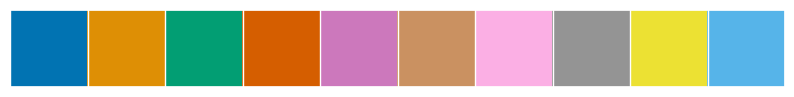

In [7]:
sns.set_style('darkgrid')
sns.set_palette('colorblind')
sns.set(font_scale=0.8)

palette = sns.color_palette('colorblind')
sns.palplot(palette)

Explarotary Data Analysis

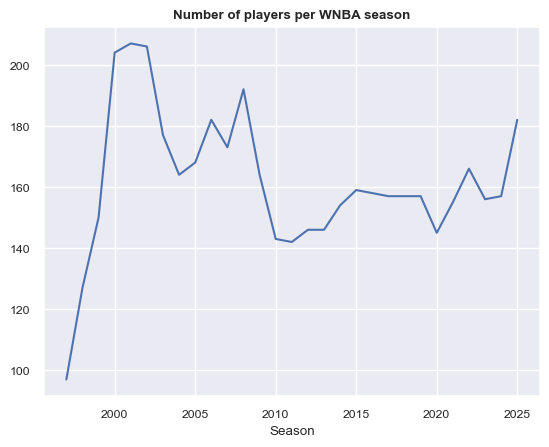

In [8]:
df['Season'].value_counts(sort=False).plot.line()
plt.title("Number of players per WNBA season", fontweight='bold')
plt.show()

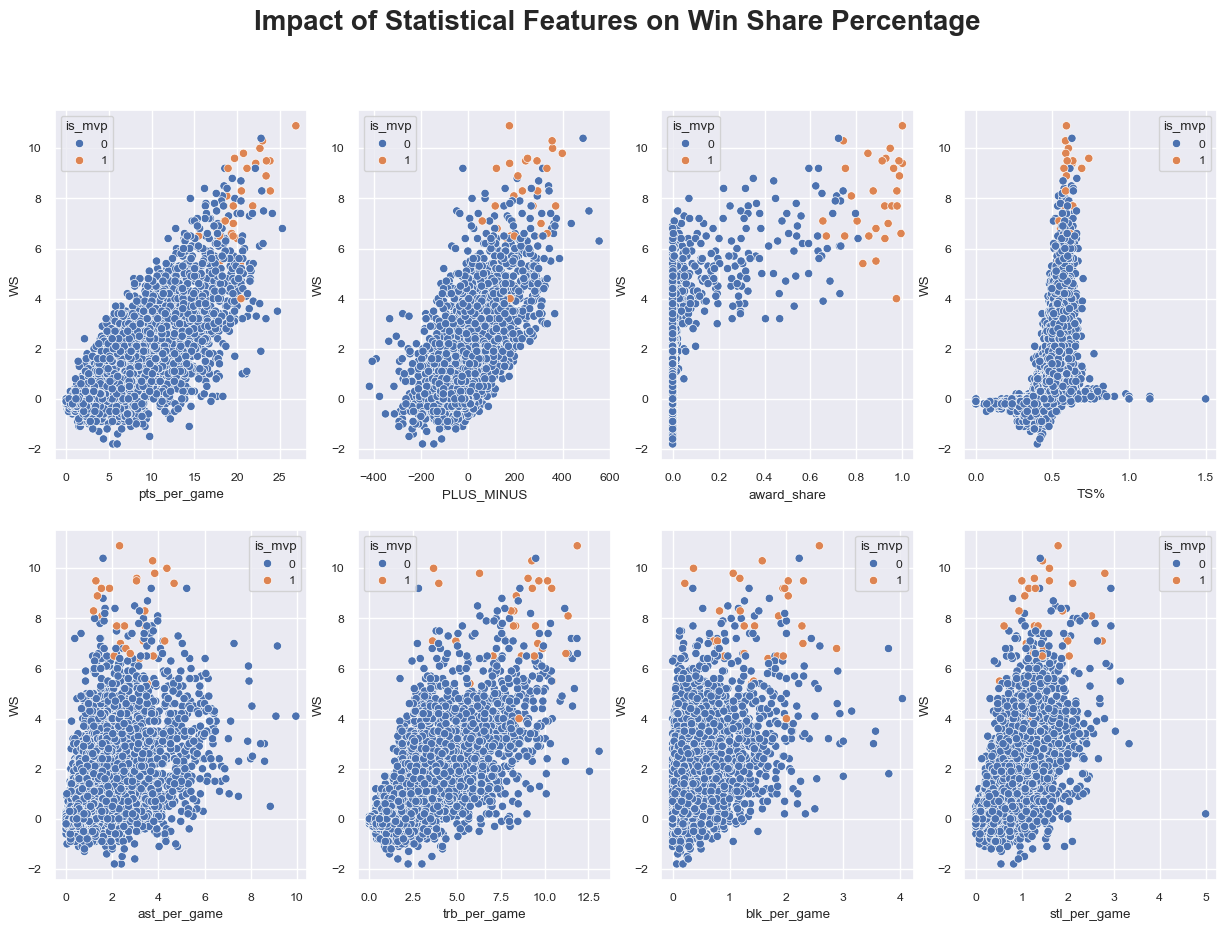

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='pts_per_game',
    y='WS',
    ax=axes[0,0]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='PLUS_MINUS',
    y='WS',
    ax=axes[0,1]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='award_share',
    ax=axes[0,2]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='TS%',
    y='WS',
    ax=axes[0,3]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='ast_per_game',
    ax=axes[1,0]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='trb_per_game',
    ax=axes[1,1]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='blk_per_game',
    ax=axes[1,2]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Impact of Statistical Features on Win Share Percentage', fontsize=20, fontweight='bold')
plt.show()

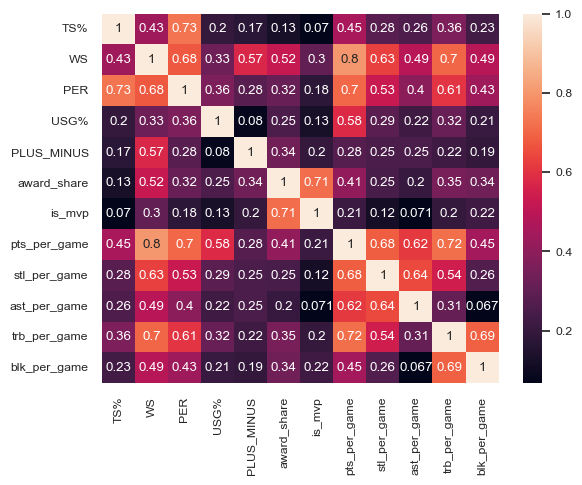

In [10]:
sns.heatmap(data=df[df.columns[2:]].corr(), annot=True)
plt.show()

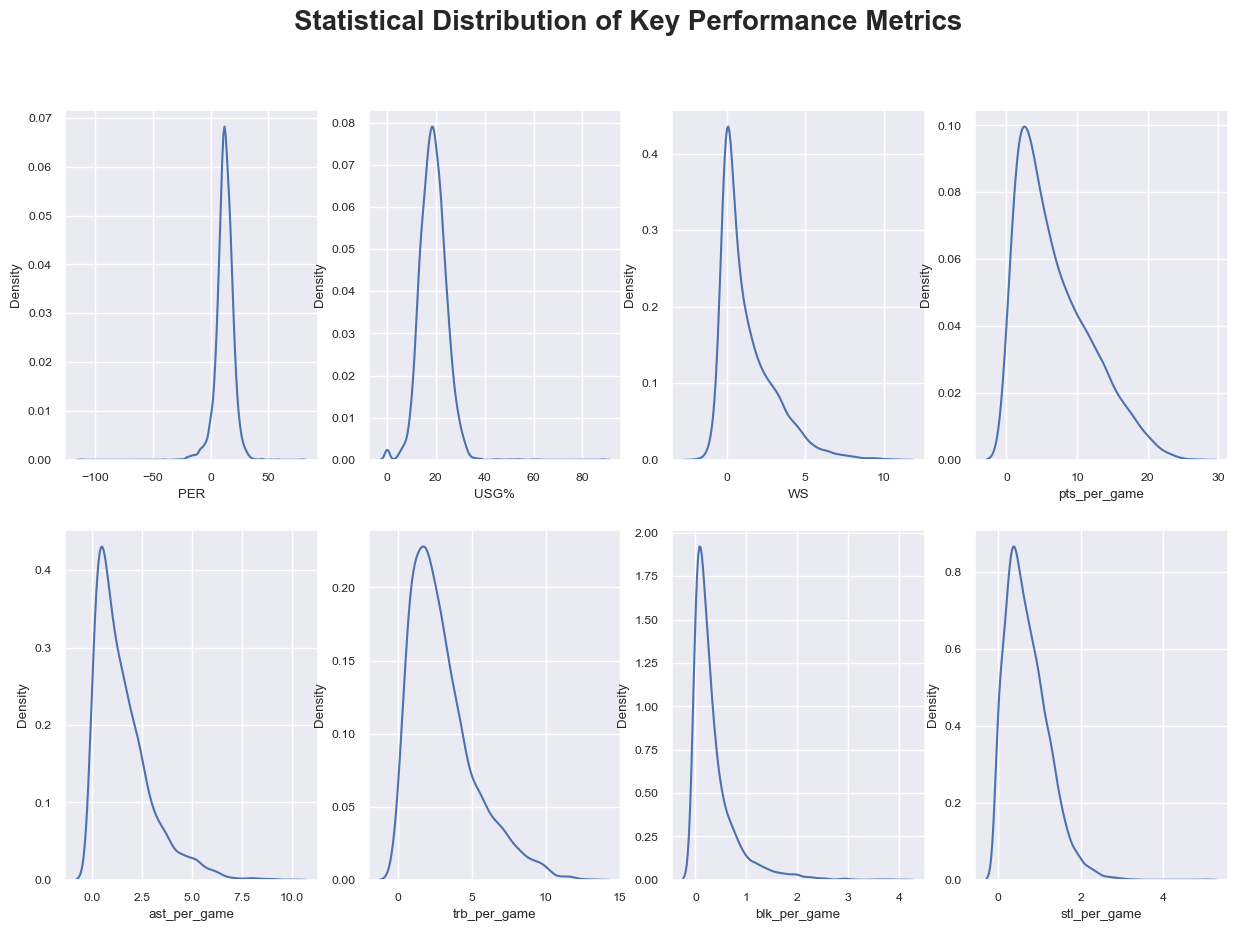

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.kdeplot(
    data=df,
    x='PER',
    ax=axes[0,0]
)
sns.kdeplot(
    data=df,
    x='USG%',
    ax=axes[0,1]
)
sns.kdeplot(
    data=df,
    x='WS',
    ax=axes[0,2]
)
sns.kdeplot(
    data=df,
    x='pts_per_game',
    ax=axes[0,3]
)
sns.kdeplot(
    data=df,
    x='ast_per_game',
    ax=axes[1,0]
)
sns.kdeplot(
    data=df,
    x='trb_per_game',
    ax=axes[1,1]
)
sns.kdeplot(
    data=df,
    x='blk_per_game',
    ax=axes[1,2]
)
sns.kdeplot(
    data=df,
    x='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Statistical Distribution of Key Performance Metrics', fontsize=20, fontweight='bold')
plt.show()

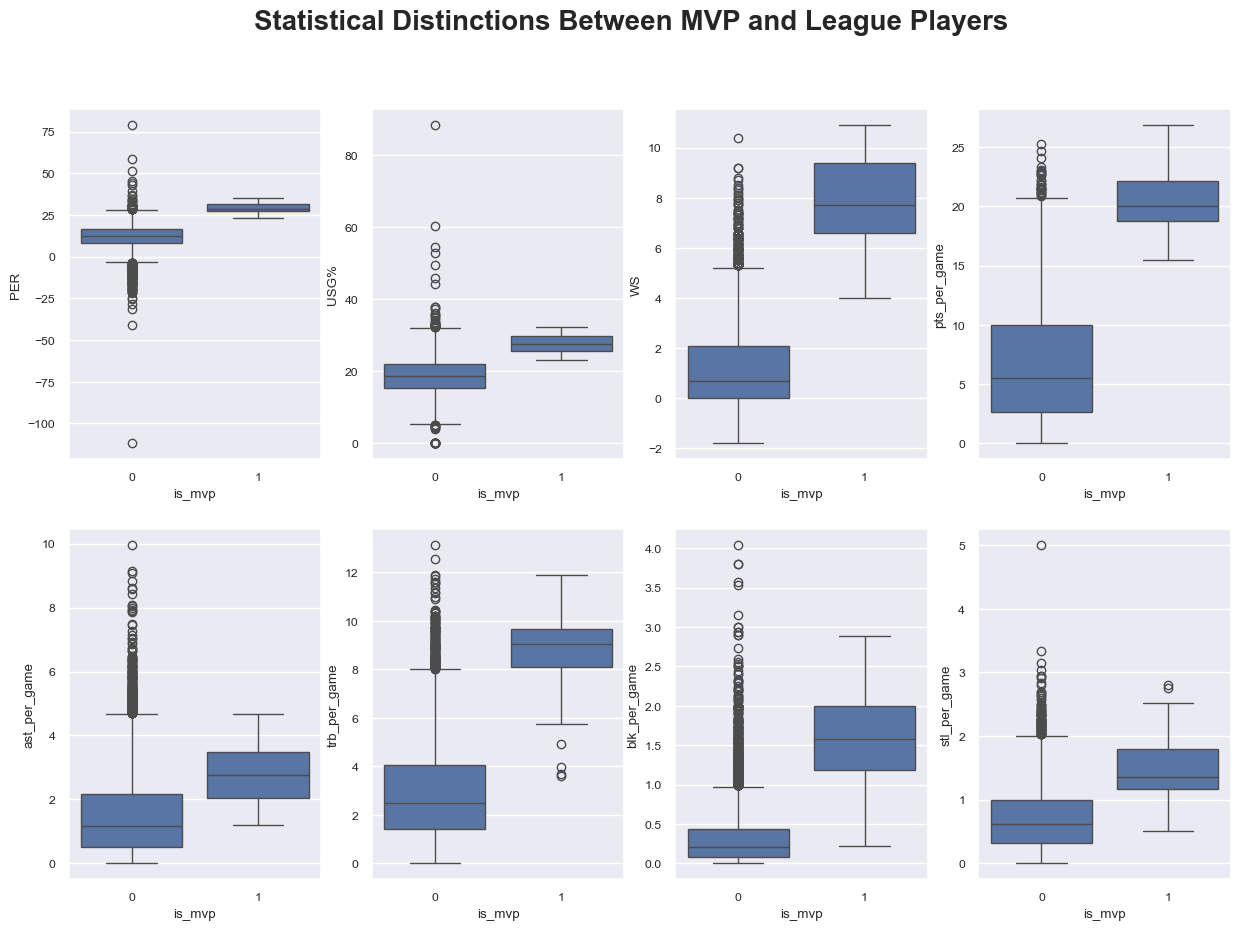

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.boxplot(
    data=df,
    x='is_mvp',
    y='PER',
    ax=axes[0,0]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='USG%',
    ax=axes[0,1]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='WS',
    ax=axes[0,2]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='pts_per_game',
    ax=axes[0,3]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='ast_per_game',
    ax=axes[1,0]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='trb_per_game',
    ax=axes[1,1]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='blk_per_game',
    ax=axes[1,2]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Statistical Distinctions Between MVP and League Players', fontsize=20, fontweight='bold')
plt.show()

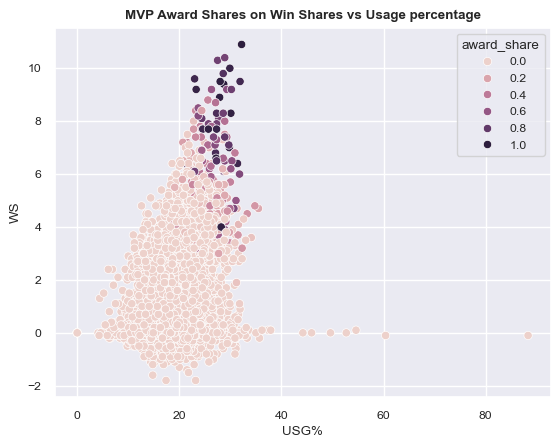

In [13]:
sns.scatterplot(data=data, x='USG%', y='WS', hue='award_share')
plt.title("MVP Award Shares on Win Shares vs Usage percentage", fontweight='bold')
plt.show()

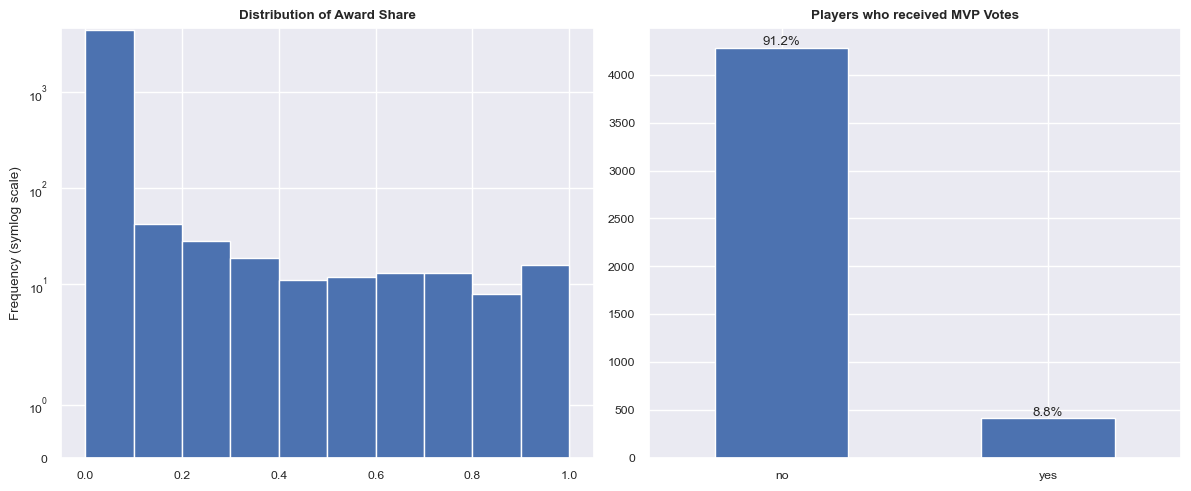

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['award_share'].plot(kind='hist', ax=axes[0])
axes[0].set_title("Distribution of Award Share", fontweight='bold')
axes[0].set_yscale('symlog')
axes[0].set_ylabel("Frequency (symlog scale)") 

pie_series = pd.Series(np.where(df['award_share'] > 0, 'yes', 'no'))

pie_series.value_counts().plot(kind='bar', ax=axes[1])

total = len(df)

# Annotate the bars
for p in axes[1].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                 
    
    axes[1].annotate(percentage, (x, y), ha='center', va='bottom')

axes[1].set_title('Players who received MVP Votes', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [15]:
X = df.drop(columns=['Season','Player','is_mvp', 'award_share'])

X_standardized = StandardScaler().fit_transform(X)
X_standardized.shape

(4691, 10)

In [16]:
tsne = TSNE(n_components=2, random_state=0)
tsne_X = tsne.fit_transform(X_standardized)
tsne_X

array([[-59.381123  ,  10.950104  ],
       [  0.44379595, -30.431894  ],
       [-49.65098   ,  -4.2110395 ],
       ...,
       [-37.842297  , -29.316021  ],
       [-32.333466  , -19.003181  ],
       [  3.402483  ,  27.515305  ]], shape=(4691, 2), dtype=float32)

In [17]:
tsne_df = pd.DataFrame(data=tsne_X, columns=["Dim_1", "Dim_2"])
tsne_df['is_mvp'] = df['is_mvp'].values
tsne_df['award_share'] = df['award_share'].values

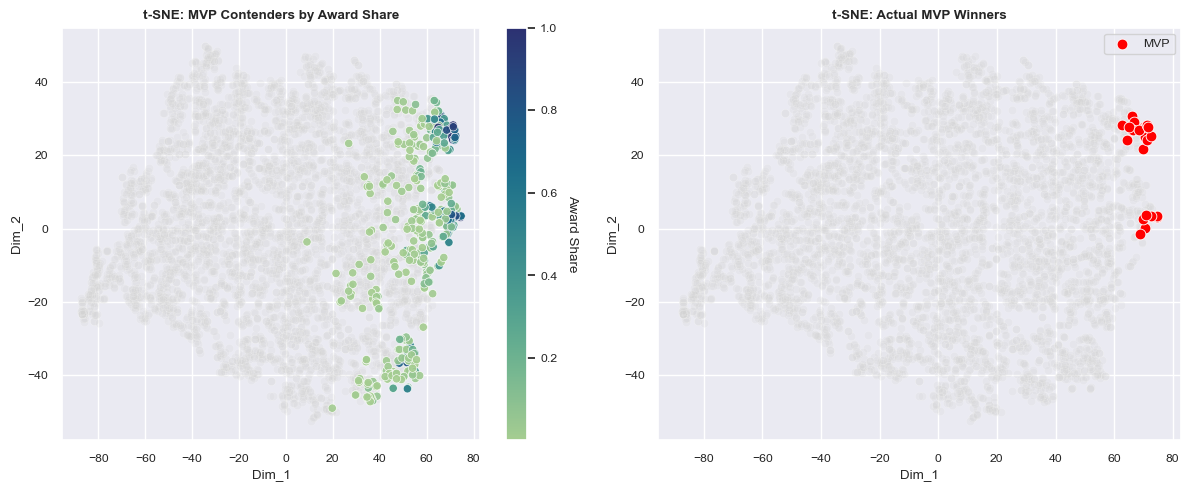

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Layer 1: The Zeros
sns.scatterplot(
    data=tsne_df[tsne_df['award_share'] == 0], 
    x='Dim_1', y='Dim_2', 
    color='lightgrey', 
    alpha=0.2, 
    ax=axes[0],
)

# Layer 2: The Contenders 
sns.scatterplot(
    data=tsne_df[tsne_df['award_share'] > 0], 
    x='Dim_1', y='Dim_2', 
    hue='award_share', 
    palette='crest', 
    alpha=0.9, 
    ax=axes[0],
    legend=False 
)

# Continuous Colorbar
min_vote = tsne_df[tsne_df['award_share'] > 0]['award_share'].min()
norm = Normalize(vmin=min_vote, vmax=1)

# a ScalarMappable object using chosen palette and normalizer
sm = plt.cm.ScalarMappable(cmap='crest', norm=norm)
sm.set_array([])

# 4. Attach the colorbar to the first subplot
cbar = fig.colorbar(sm, ax=axes[0])
cbar.set_label('Award Share', rotation=270, labelpad=15) # Add a nice label

axes[0].set_title("t-SNE: MVP Contenders by Award Share", fontweight='bold')


# Plot 2: is_mvp 
sns.scatterplot(
    data=tsne_df[tsne_df['is_mvp'] == 0], 
    x='Dim_1', y='Dim_2', color='lightgrey', alpha=0.2, ax=axes[1]
)

sns.scatterplot(
    data=tsne_df[tsne_df['is_mvp'] == 1], 
    x='Dim_1', y='Dim_2', color='red', alpha=1.0, s=60, ax=axes[1], label='MVP'
)
axes[1].set_title("t-SNE: Actual MVP Winners", fontweight='bold')

plt.tight_layout()
plt.show()

Regression Tree Based Models For Prediction using Award Shares Variable. 

normalize features within season
What actually determines MVP voting is how dominant a player was relative to her peers that year — not her raw numbers.

In [19]:
season_cols = ['TS%', 'WS', 'PER', 'USG%', 'pts_per_game', 'ast_per_game',
               'trb_per_game', 'blk_per_game', 'stl_per_game'] # plus minus is a season total, not a per-game rate

for col in season_cols:
    df[f'{col}_z'] = df.groupby('Season')[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )
df.columns    

Index(['Season', 'Player', 'TS%', 'WS', 'PER', 'USG%', 'PLUS_MINUS',
       'award_share', 'is_mvp', 'pts_per_game', 'stl_per_game', 'ast_per_game',
       'trb_per_game', 'blk_per_game', 'TS%_z', 'WS_z', 'PER_z', 'USG%_z',
       'pts_per_game_z', 'ast_per_game_z', 'trb_per_game_z', 'blk_per_game_z',
       'stl_per_game_z'],
      dtype='str')

In [20]:
df_sorted = df.sort_values(by=['Season', 'Player']).reset_index(drop=True)

features = ['TS%_z', 'WS_z', 'PER_z', 'USG%_z','pts_per_game_z', 'ast_per_game_z',
             'trb_per_game_z', 'blk_per_game_z','stl_per_game_z']
target = 'award_share'

Hyperparameter tuning using optuna then Training and testing

In [21]:
def walk_forward_validation(estimator,features,target ,df=df,start_test_year=1999, end_test_year=2025):
    yearly_r2 = {}
    yearly_rmse = {}
    all_model_predictions = []

    for test_year in range(start_test_year, end_test_year+1):
        
        train_data = df[df['Season'] < test_year]
        test_data = df[df['Season'] == test_year]

        X_train, y_train = train_data[features], train_data[target]
        X_test, y_test = test_data[features], test_data[target]
        
        estimator.fit(X_train, y_train)
        
        y_pred = estimator.predict(X_test)

        eval_df = pd.DataFrame({
            'Season': test_data['Season'].values,
            'Player': test_data['Player'].values,
            'Actual_Share': y_test.values,
            'Predicted_Share': y_pred
        })
    
        eval_df['Predicted_Share'] = eval_df['Predicted_Share'].clip(lower=0)
        all_model_predictions.append(eval_df)

        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred)**(1/2)

        yearly_r2[test_year] = r2
        yearly_rmse[test_year] = rmse
    
    final_predictions_df = pd.concat(all_model_predictions, ignore_index=True)
    overall_r2 = sum(yearly_r2.values())/len(yearly_r2.keys())
    overall_rmse = sum(yearly_rmse.values())/len(yearly_rmse.keys())
    
    return {'overall_r2':overall_r2, 'overall_rmse':overall_rmse, 'final_predictions':final_predictions_df}

In [22]:
def xgb_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'eta': trial.suggest_float('eta', 0.01, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'random_state': 0,
    }
    results = walk_forward_validation(
        estimator=xgboost.XGBRegressor(**params),
        features=features, target=target, df=df_sorted,
        start_test_year=2010, end_test_year=2025
    )
    return results['overall_r2']

In [23]:
study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=40)
print(study.best_params, study.best_value)

[I 2026-06-21 00:39:28,268] A new study created in memory with name: no-name-5f3275b8-8569-4574-be4d-a89ce1a9ff58
[I 2026-06-21 00:39:33,593] Trial 0 finished with value: 0.7268543274005836 and parameters: {'max_depth': 6, 'eta': 0.09086271207744133, 'n_estimators': 499, 'subsample': 0.8097087625043362}. Best is trial 0 with value: 0.7268543274005836.
[I 2026-06-21 00:39:42,089] Trial 1 finished with value: 0.7374205963256897 and parameters: {'max_depth': 7, 'eta': 0.018937001120240514, 'n_estimators': 534, 'subsample': 0.6035094987933576}. Best is trial 1 with value: 0.7374205963256897.
[I 2026-06-21 00:39:48,811] Trial 2 finished with value: 0.7234984382048419 and parameters: {'max_depth': 6, 'eta': 0.07885457970718023, 'n_estimators': 725, 'subsample': 0.8462403228423817}. Best is trial 1 with value: 0.7374205963256897.
[I 2026-06-21 00:39:56,906] Trial 3 finished with value: 0.7365834743092362 and parameters: {'max_depth': 6, 'eta': 0.019120657070588867, 'n_estimators': 568, 'subsa

{'max_depth': 4, 'eta': 0.012773306741919534, 'n_estimators': 362, 'subsample': 0.6827613022759571} 0.7487921428842502


In [24]:
def catb_objective(trial):
    params = {
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'iterations': trial.suggest_int('iterations', 200, 800),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'loss_function': 'RMSE',
        'random_state': 0,
        'verbose': 0,
    }
    results = walk_forward_validation(
        estimator=catboost.CatBoostRegressor(**params),
        features=features, target=target, df=df_sorted,
        start_test_year=2010, end_test_year=2025 
    )
    return results['overall_r2']

study2 = optuna.create_study(direction='maximize')
study2.optimize(catb_objective, n_trials=40)
print(study2.best_params, study2.best_value)

[I 2026-06-21 00:42:13,639] A new study created in memory with name: no-name-33bbd015-5c3a-47e3-a534-0890583a1b66
[I 2026-06-21 00:42:20,479] Trial 0 finished with value: 0.7237090627451229 and parameters: {'depth': 3, 'learning_rate': 0.061053335048500315, 'iterations': 381, 'l2_leaf_reg': 7.054891315771352}. Best is trial 0 with value: 0.7237090627451229.
[I 2026-06-21 00:42:29,395] Trial 1 finished with value: 0.7347075785112464 and parameters: {'depth': 4, 'learning_rate': 0.016060502371462435, 'iterations': 451, 'l2_leaf_reg': 7.254422711740724}. Best is trial 1 with value: 0.7347075785112464.
[I 2026-06-21 00:42:37,191] Trial 2 finished with value: 0.7153441466313714 and parameters: {'depth': 4, 'learning_rate': 0.07218292651117546, 'iterations': 386, 'l2_leaf_reg': 4.4905648225503745}. Best is trial 1 with value: 0.7347075785112464.
[I 2026-06-21 00:42:49,434] Trial 3 finished with value: 0.7306763200900426 and parameters: {'depth': 7, 'learning_rate': 0.049229344630469435, 'ite

{'depth': 3, 'learning_rate': 0.024500159421583276, 'iterations': 277, 'l2_leaf_reg': 5.610492949525419} 0.738199112539097


In [25]:
catb = catboost.CatBoostRegressor(**study2.best_params)
xgb = xgboost.XGBRegressor(**study.best_params)

In [26]:
raw_features = ['TS%', 'WS', 'PER', 'USG%', 'pts_per_game',
                'ast_per_game', 'trb_per_game', 'blk_per_game', 'stl_per_game']

z_features = ['TS%_z', 'WS_z', 'PER_z', 'USG%_z', 'pts_per_game_z',
              'ast_per_game_z', 'trb_per_game_z', 'blk_per_game_z', 'stl_per_game_z']

default_params = dict(loss_function='RMSE', random_state=0, verbose=0)  # identical params both runs

raw_results = walk_forward_validation(
    catboost.CatBoostRegressor(**default_params), raw_features, target, df_sorted
)
z_results = walk_forward_validation(
    catboost.CatBoostRegressor(**default_params), z_features, target, df_sorted
)

print("Raw R²:", raw_results['overall_r2'])
print("Season-normalized R²:", z_results['overall_r2'])

Raw R²: 0.6461307708148892
Season-normalized R²: 0.686181806998142


In [29]:
catb_results = walk_forward_validation(
                estimator=catb,
                features=features,
                target=target)

print(f'r2: {catb_results['overall_r2']}')
print(f'rmse: {catb_results['overall_rmse']}')

catb_sorted_preds = catb_results['final_predictions'].sort_values(
    by=['Season', 'Predicted_Share'], 
    ascending=[True, False]
)

predicted_mvps_catb = catb_sorted_preds.groupby('Season').head(1).reset_index(drop=True)

predicted_mvps_catb[['Season', 'Player', 'Predicted_Share', 'Actual_Share']]

0:	learn: 0.1091050	total: 613us	remaining: 169ms
1:	learn: 0.1083154	total: 1.2ms	remaining: 166ms
2:	learn: 0.1075154	total: 1.97ms	remaining: 180ms
3:	learn: 0.1066026	total: 2.68ms	remaining: 183ms
4:	learn: 0.1059997	total: 3.52ms	remaining: 192ms
5:	learn: 0.1051332	total: 4.07ms	remaining: 184ms
6:	learn: 0.1042745	total: 4.76ms	remaining: 184ms
7:	learn: 0.1035448	total: 5.45ms	remaining: 183ms
8:	learn: 0.1026303	total: 6.22ms	remaining: 185ms
9:	learn: 0.1018912	total: 7.4ms	remaining: 198ms
10:	learn: 0.1010988	total: 8.03ms	remaining: 194ms
11:	learn: 0.1003959	total: 8.82ms	remaining: 195ms
12:	learn: 0.0995808	total: 9.51ms	remaining: 193ms
13:	learn: 0.0988446	total: 10.3ms	remaining: 194ms
14:	learn: 0.0980435	total: 11ms	remaining: 192ms
15:	learn: 0.0975271	total: 11.9ms	remaining: 195ms
16:	learn: 0.0967526	total: 12.6ms	remaining: 192ms
17:	learn: 0.0963217	total: 13.3ms	remaining: 192ms
18:	learn: 0.0956355	total: 14ms	remaining: 191ms
19:	learn: 0.0949490	total: 1

,Season,Player,Predicted_Share,Actual_Share
0,1999,Cynthia Cooper,0.773732,0.635
1,2000,Sheryl Swoopes,0.764067,0.850
2,2001,Katie Smith,0.475829,0.297
3,2002,Tamika Catchings,0.660264,0.593
4,2003,Lauren Jackson,0.776243,0.752
5,2004,Lauren Jackson,0.660302,0.731
6,2005,Lauren Jackson,0.595557,0.650
7,2006,Diana Taurasi,0.557935,0.384
8,2007,Lauren Jackson,0.657853,0.985
9,2008,Candace Parker,0.634096,0.923


In [30]:
xgb_results = walk_forward_validation(
    estimator=xgb,
    features=features,
    target=target
    )

print(f'r2: {xgb_results['overall_r2']}')
print(f'rmse: {xgb_results['overall_rmse']}')

xgb_sorted_preds = xgb_results['final_predictions'].sort_values(
    by=['Season', 'Predicted_Share'], 
    ascending=[True, False]
)

predicted_mvps_xgb = xgb_sorted_preds.groupby('Season').head(1).reset_index(drop=True)

predicted_mvps_xgb[['Season', 'Player', 'Predicted_Share', 'Actual_Share']]

r2: 0.6987022420374075
rmse: 0.05044405723619002


,Season,Player,Predicted_Share,Actual_Share
0,1999,Cynthia Cooper,0.736799,0.635
1,2000,Sheryl Swoopes,0.768802,0.850
2,2001,Lisa Leslie,0.593696,0.938
3,2002,Tamika Catchings,0.701813,0.593
4,2003,Lauren Jackson,0.844424,0.752
5,2004,Lauren Jackson,0.753354,0.731
6,2005,Lauren Jackson,0.646959,0.650
7,2006,Diana Taurasi,0.559004,0.384
8,2007,Lauren Jackson,0.500122,0.985
9,2008,Diana Taurasi,0.732745,0.497


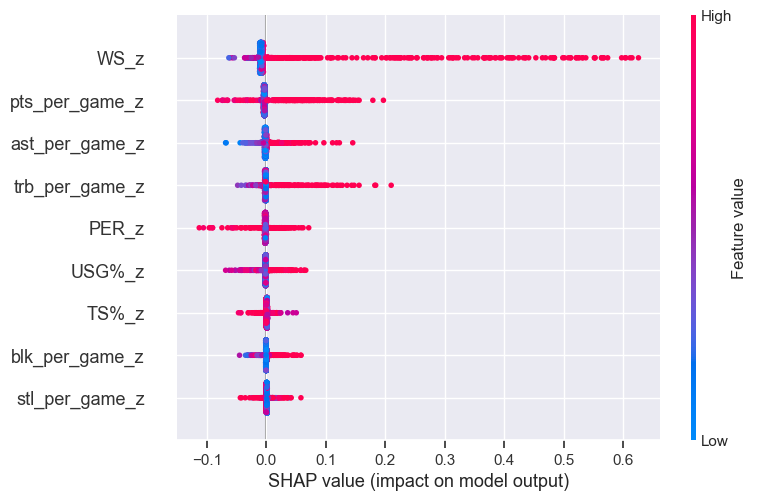

In [31]:
xgb_explainer = shap.TreeExplainer(xgb)
xgb_shap_values = xgb_explainer(df[features])
shap.summary_plot(xgb_shap_values, df[features])

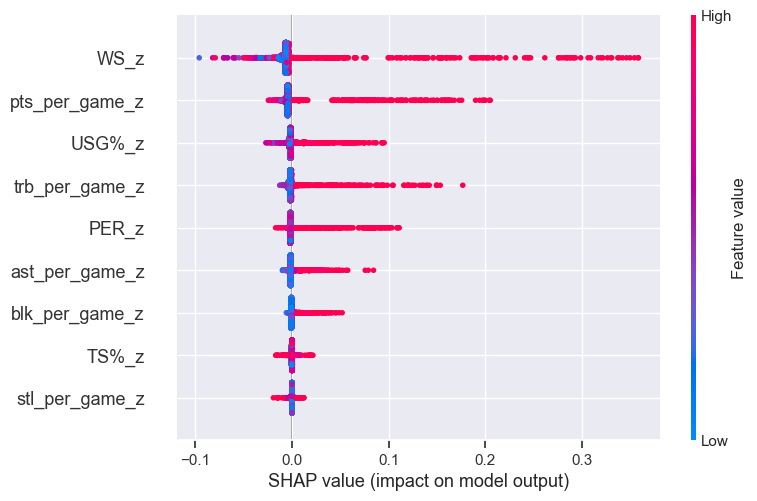

In [32]:
explainer = shap.TreeExplainer(catb)
shap_values = explainer(df[features])

shap.summary_plot(shap_values, df[features])


one feature model

In [33]:
from scipy.stats import spearmanr
baseline_corr = spearmanr(df['WS'], df['award_share'])
baseline_corr

SignificanceResult(statistic=np.float64(0.4468678023544195), pvalue=np.float64(4.015317217985721e-229))

In [34]:
single_feature_results = walk_forward_validation(
       estimator=catboost.CatBoostRegressor(iterations=300, learning_rate=0.05, verbose=0, random_state=0),
       features=['WS_z'], target=target, df=df_sorted
   )
print(single_feature_results['overall_r2'])

0.577342829432439
